In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import math
import matplotlib.ticker as ticker

df_terrestre = pd.read_csv("../../data/Experimental/transporte_terrestre_clean.csv",
                      encoding="utf-8-sig",
                      dtype=str,
                      keep_default_na=False,
                      na_filter=False
                      )

In [103]:
from pathlib import Path
import os
try:
    BASE_DIR = Path(__file__).resolve().parents[2]
except NameError:
    # Si estás en notebook o entorno interactivo
    BASE_DIR = Path(os.getcwd())

BASE_DIR = Path(r"C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM")
ASSETS_DIR = BASE_DIR / "assets"
ASSETS_DIR.mkdir(parents=True, exist_ok=True)



In [104]:
# 2) Convertir columnas numéricas (ajusta si tienes más)
for col in ["viajeros"]:
    if col in df_terrestre.columns:
        df_terrestre[col] = pd.to_numeric(df_terrestre[col], errors="coerce")

In [105]:
df_terrestre.shape

(140, 5)

In [106]:
df_terrestre.head()

,año,mes,viajeros,modo_transporte,distancia_tipo
0,2023,1,2722000,ferrocarril,larga
1,2023,1,3238000,ferrocarril,media
2,2023,1,1122000,autobus,larga
3,2023,1,15908000,autobus,media
4,2023,2,2688000,ferrocarril,larga


In [107]:
# Información general
df_terrestre.info()

# Tabla estructurada tipo diccionario de datos
eda_structure = pd.DataFrame({
    "Column Name": df_terrestre.columns,
    "Data Type": df_terrestre.dtypes.values,
    "NULLs allowed": ["Y" if df_terrestre[c].isna().any() else "N" for c in df_terrestre.columns],
    "NULL %": [round(df_terrestre[c].isna().mean()*100, 2) for c in df_terrestre.columns]
})

eda_structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   año              140 non-null    object
 1   mes              140 non-null    object
 2   viajeros         140 non-null    int64 
 3   modo_transporte  140 non-null    object
 4   distancia_tipo   140 non-null    object
dtypes: int64(1), object(4)
memory usage: 5.6+ KB


,Column Name,Data Type,NULLs allowed,NULL %
0,año,object,N,0.0
1,mes,object,N,0.0
2,viajeros,int64,N,0.0
3,modo_transporte,object,N,0.0
4,distancia_tipo,object,N,0.0


In [108]:
def analizar_dataframe_para_postgres(df, nombre_df="dataset"):

    resultados = []

    for col in df.columns:
        serie = df[col]
        dtype = serie.dtype
        nulos = serie.isna().sum()

        info = {
            "dataset": nombre_df,
            "columna": col,
            "dtype_pandas": str(dtype),
            "nulos": nulos
        }

        # ----------------------------
        # VARIABLES TEXTO
        # ----------------------------
        if dtype == "object":
            max_len = serie.astype(str).str.len().max()
            info["tipo_detectado"] = "texto"
            info["max_longitud"] = max_len

        # ----------------------------
        # VARIABLES NUMÉRICAS ENTERAS
        # ----------------------------
        elif np.issubdtype(dtype, np.integer):
            info["tipo_detectado"] = "entero"
            info["min"] = serie.min()
            info["max"] = serie.max()

        # ----------------------------
        # VARIABLES DECIMALES
        # ----------------------------
        elif np.issubdtype(dtype, np.floating):
            info["tipo_detectado"] = "decimal"
            info["min"] = serie.min()
            info["max"] = serie.max()

            # calcular decimales reales
            decimales = (
                serie.dropna()
                .astype(str)
                .str.split(".")
                .str[1]
                .str.len()
                .max()
            )
            info["max_decimales_observados"] = decimales

        else:
            info["tipo_detectado"] = "otro"

        resultados.append(info)

    return pd.DataFrame(resultados)

In [109]:
resumen_terrestre = analizar_dataframe_para_postgres(df_terrestre, "Transporte terrestre")
display(resumen_terrestre)

,dataset,columna,dtype_pandas,nulos,tipo_detectado,max_longitud,min,max
0,Transporte terrestre,año,object,0,texto,4.0,NaN,NaN
1,Transporte terrestre,mes,object,0,texto,2.0,NaN,NaN
2,Transporte terrestre,viajeros,int64,0,entero,NaN,972000.0,26868000.0
3,Transporte terrestre,modo_transporte,object,0,texto,11.0,NaN,NaN
4,Transporte terrestre,distancia_tipo,object,0,texto,5.0,NaN,NaN


## =========================
## 2) PREGUNTA 1
## ¿Qué modo de transporte terrestre es más utilizado en España?
## =========================

In [110]:
print("\n===== PREGUNTA 1: MODO MÁS UTILIZADO =====")

viajeros_por_modo = (
    df_terrestre.groupby("modo_transporte")["viajeros"]
    .sum()
    .sort_values(ascending=False)
)

total_viajeros = viajeros_por_modo.sum()

resultado = pd.DataFrame({
    "Total_Viajeros": viajeros_por_modo,
    "Porcentaje_%": (viajeros_por_modo / total_viajeros * 100).round(2)
})

print("\nResumen (Total y %):")
print(resultado)

modo_top = resultado.index[0]
viajeros_top = int(resultado.iloc[0]["Total_Viajeros"])
pct_top = float(resultado.iloc[0]["Porcentaje_%"])
print(f"\n➡️ Modo más utilizado: {modo_top} | Total: {viajeros_top:,} | %: {pct_top:.2f}%")


===== PREGUNTA 1: MODO MÁS UTILIZADO =====

Resumen (Total y %):
                 Total_Viajeros  Porcentaje_%
modo_transporte                              
autobus               792144000         73.43
ferrocarril           286628000         26.57

➡️ Modo más utilizado: autobus | Total: 792,144,000 | %: 73.43%


# =========================
# 3) GRÁFICO: Total por modo (eje Y en millones) + GUARDAR
# =========================

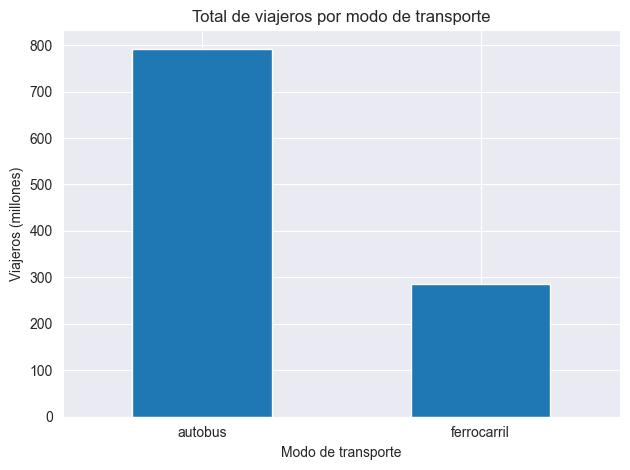

In [111]:
plt.figure()
resultado["Total_Viajeros"].plot(kind="bar")

plt.title("Total de viajeros por modo de transporte")
plt.ylabel("Viajeros (millones)")
plt.xlabel("Modo de transporte")
plt.xticks(rotation=0)

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{x/1e6:.0f}"))

plt.tight_layout()

  # Guardar en assets

plt.savefig(ASSETS_DIR / "total_viajeros_por_modo.png", dpi=300)
plt.show()
plt.close()


El autobús concentra la mayor parte de la demanda de transporte terrestre en España, con un volumen de viajeros significativamente superior al ferrocarril durante el período analizado.
La diferencia de magnitud sugiere que el autobús constituye el principal soporte del sistema de movilidad terrestre, mientras que el ferrocarril cumple un rol más específico.
La comparación en valores absolutos (millones de viajeros) permite dimensionar el impacto real de cada modo en el sistema de transporte.


# =========================
# 4) EVOLUCIÓN MENSUAL (2 GRÁFICOS separados) + GUARDAR
# =========================

In [112]:
print(df_terrestre["mes"].head(), df_terrestre["mes"].dtype)
print(df_terrestre["viajeros"].head(), df_terrestre["viajeros"].dtype)

0    1
1    1
2    1
3    1
4    2
Name: mes, dtype: object object
0     2722000
1     3238000
2     1122000
3    15908000
4     2688000
Name: viajeros, dtype: int64 int64


In [113]:
df_terrestre["fecha"] = pd.to_datetime(
    df_terrestre["año"].astype(str) + "-" +
    df_terrestre["mes"].astype(str).str.zfill(2) + "-01",
    format="%Y-%m-%d",
    errors="coerce"
)

In [115]:
print("Nulos en fecha:", df_terrestre["fecha"].isna().sum())
print(df_terrestre[["año","mes","fecha"]].head())

Nulos en fecha: 0
    año mes      fecha
0  2023   1 2023-01-01
1  2023   1 2023-01-01
2  2023   1 2023-01-01
3  2023   1 2023-01-01
4  2023   2 2023-02-01


In [116]:
# Viajeros numérico
df_terrestre["viajeros"] = (
        df_terrestre["viajeros"].astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
df_terrestre["viajeros"] = pd.to_numeric(df_terrestre["viajeros"], errors="coerce")

In [117]:
print(df_terrestre["modo_transporte"].unique())

['ferrocarril' 'autobus']


In [118]:
print(df_terrestre[["año","mes","fecha","modo_transporte","viajeros"]].head())
print(df_terrestre[["fecha","viajeros"]].isna().sum())
print(df_terrestre["fecha"].dtype, df_terrestre["viajeros"].dtype)

    año mes      fecha modo_transporte  viajeros
0  2023   1 2023-01-01     ferrocarril   2722000
1  2023   1 2023-01-01     ferrocarril   3238000
2  2023   1 2023-01-01         autobus   1122000
3  2023   1 2023-01-01         autobus  15908000
4  2023   2 2023-02-01     ferrocarril   2688000
fecha       0
viajeros    0
dtype: int64
datetime64[ns] int64


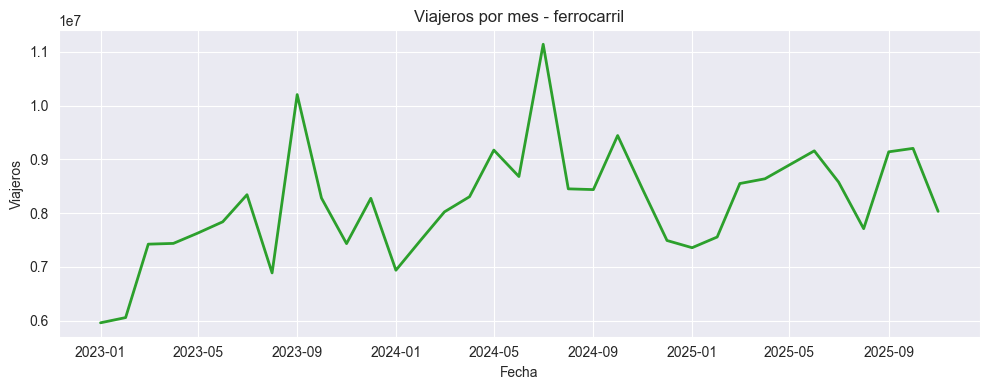

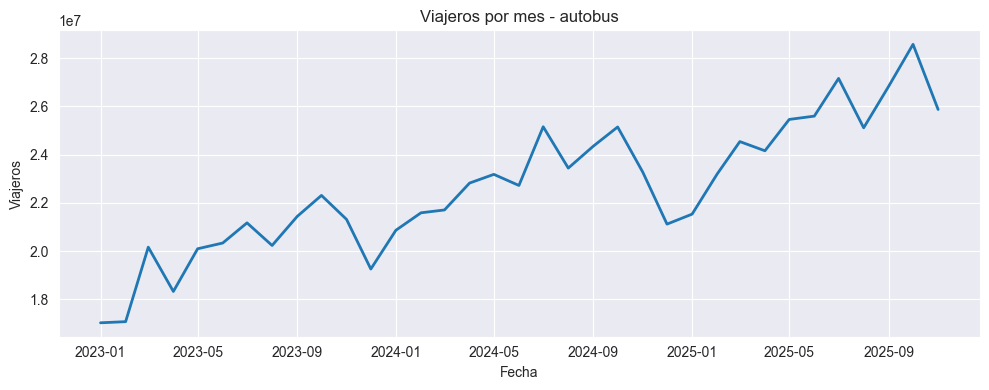

In [119]:
def plot_modo(modo: str, color: str, filename: str):
    serie = (
        df_terrestre[df_terrestre["modo_transporte"] == modo]
        .groupby("fecha")["viajeros"]
        .sum()
    )

    plt.figure(figsize=(10, 4))
    plt.plot(serie.index, serie.values, color=color, linewidth=2)
    plt.title(f"Viajeros por mes - {modo}")
    plt.xlabel("Fecha")
    plt.ylabel("Viajeros")
    plt.tight_layout()
    plt.savefig(ASSETS_DIR / filename, dpi=300)
    plt.show()
    plt.close()

plot_modo("ferrocarril", color="tab:green", filename="viajeros_mes_ferrocarril.png")
plot_modo("autobus", color="tab:blue", filename="viajeros_mes_autobus.png")



Ambos modos presentan patrones estacionales similares, lo que indica que están influenciados por factores comunes como periodos vacacionales y movilidad recurrente.
El autobús mantiene un volumen de viajeros consistentemente superior en todos los meses, sin cruces entre series, lo que refuerza su predominancia estructural.
El ferrocarril muestra mayor variabilidad mensual, sugiriendo una mayor sensibilidad a factores coyunturales y una demanda menos estable.
La visualización conjunta permite identificar que el crecimiento del autobús es más sostenido, mientras que el ferrocarril presenta picos y caídas más marcadas.


# =========================
# 5) COMPARACIÓN MENSUAL EN UN SOLO GRÁFICO (millones) + GUARDAR
# =========================

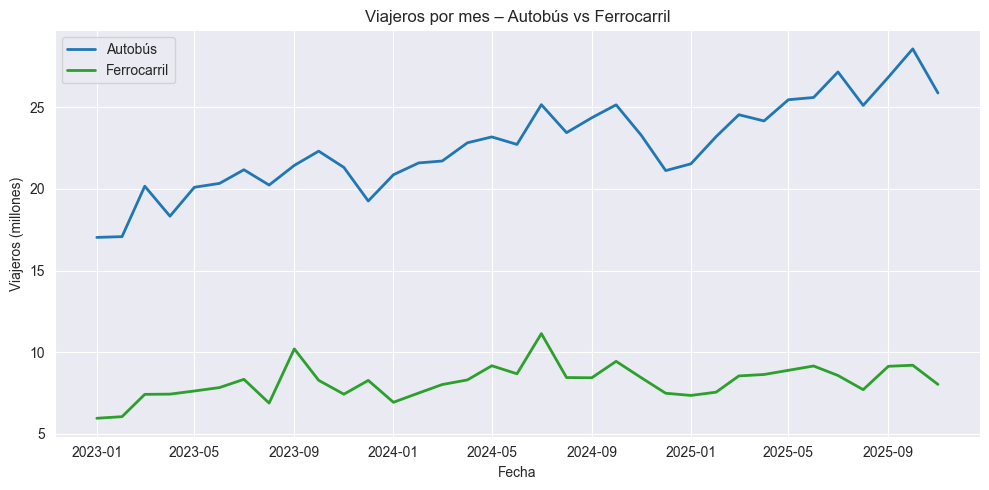

In [122]:
serie_autobus = (
    df_terrestre[df_terrestre["modo_transporte"] == "autobus"]
    .groupby("fecha")["viajeros"]
    .sum()
)

serie_ferrocarril = (
    df_terrestre[df_terrestre["modo_transporte"] == "ferrocarril"]
    .groupby("fecha")["viajeros"]
    .sum()
)

plt.figure(figsize=(10, 5))

plt.plot(
    serie_autobus.index,
    serie_autobus.values,
    label="Autobús",
    color="tab:blue",
    linewidth=2
)

plt.plot(
    serie_ferrocarril.index,
    serie_ferrocarril.values,
    label="Ferrocarril",
    color="tab:green",
    linewidth=2
)

plt.title("Viajeros por mes – Autobús vs Ferrocarril")
plt.xlabel("Fecha")
plt.ylabel("Viajeros (millones)")

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{x/1e6:.0f}"))

plt.legend()
plt.tight_layout()
plt.savefig(ASSETS_DIR / "viajeros_mensual_autobus_vs_ferrocarril.png", dpi=300)
plt.show()
plt.close()

# =========================
# 6A) TABLA ANUAL: total por año y modo + % participación
# =========================

In [123]:
tabla_anual = (
    df_terrestre.groupby(["año", "modo_transporte"])["viajeros"]
    .sum()
    .reset_index()
    .sort_values(["año", "viajeros"], ascending=[True, False])
)

tabla_anual["pct_en_el_año"] = (
    tabla_anual["viajeros"] / tabla_anual.groupby("año")["viajeros"].transform("sum") * 100
).round(2)

print("\n===== TABLA ANUAL (Total + % dentro del año) =====")
print(tabla_anual)


===== TABLA ANUAL (Total + % dentro del año) =====
    año modo_transporte   viajeros  pct_en_el_año
0  2023         autobus  238758000          72.24
1  2023     ferrocarril   91771000          27.76
2  2024         autobus  275367000          72.96
3  2024     ferrocarril  102032000          27.04
4  2025         autobus  278019000          74.97
5  2025     ferrocarril   92825000          25.03


# =========================
# 6B) GRÁFICO: EVOLUCIÓN ANUAL POR MODO (millones) + GUARDAR
# =========================

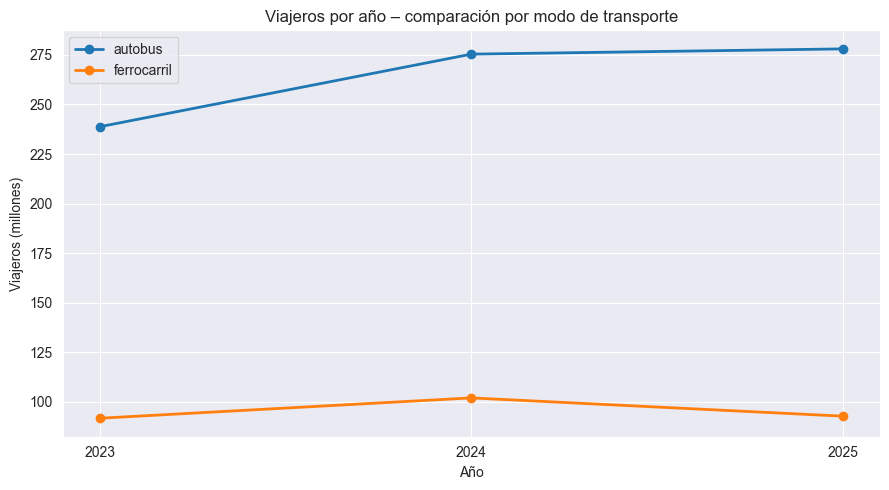

In [124]:
anual_pivot = (
    df_terrestre.groupby(["año", "modo_transporte"])["viajeros"]
    .sum()
    .reset_index()
    .pivot(index="año", columns="modo_transporte", values="viajeros")
    .sort_index()
)

plt.figure(figsize=(9, 5))
for modo in anual_pivot.columns:
    plt.plot(anual_pivot.index, anual_pivot[modo], marker="o", linewidth=2, label=modo)

plt.title("Viajeros por año – comparación por modo de transporte")
plt.xlabel("Año")
plt.ylabel("Viajeros (millones)")

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{x/1e6:.0f}"))

plt.legend()
plt.tight_layout()
plt.savefig(ASSETS_DIR/ "viajeros_anual_por_modo.png", dpi=300)
plt.show()
plt.close()

In [ ]:
# =========================
# 6C) CRECIMIENTO INTERANUAL (YoY %) POR MODO
# =========================

In [125]:
yoy = (anual_pivot.pct_change() * 100).round(2)

print("\n===== Crecimiento interanual (YoY %) por modo =====")
print(yoy)



===== Crecimiento interanual (YoY %) por modo =====
modo_transporte  autobus  ferrocarril
año                                  
2023                 NaN          NaN
2024               15.33        11.18
2025                0.96        -9.02


# =========================
# 7A) PESO RELATIVO GLOBAL POR TIPO DE DISTANCIA + GRÁFICO + GUARDAR
# =========================

In [126]:
distancia_global = (
    df_terrestre.groupby("distancia_tipo")["viajeros"]
    .sum()
    .sort_values(ascending=False)
)

total_viajeros_dist = distancia_global.sum()

peso_global = pd.DataFrame({
    "Total_Viajeros": distancia_global,
    "Porcentaje_%": (distancia_global / total_viajeros_dist * 100).round(2)
})

print("\n===== PESO RELATIVO GLOBAL POR DISTANCIA =====")
print(peso_global)

plt.figure()
peso_global["Porcentaje_%"].plot(
    kind="bar",
    color=["tab:blue", "tab:green"]  # media / larga (si cambia el orden, igual se ve bien)
)

plt.title("Peso relativo de la demanda por tipo de distancia")
plt.ylabel("Porcentaje del total (%)")
plt.xlabel("Tipo de distancia")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(ASSETS_DIR / "peso_relativo_distancia.png", dpi=300)
plt.close()

print(f"\n✅ Gráficos guardados en: {ASSETS_DIR}")



===== PESO RELATIVO GLOBAL POR DISTANCIA =====
                Total_Viajeros  Porcentaje_%
distancia_tipo                              
media                886347000         82.16
larga                192425000         17.84

✅ Gráficos guardados en: C:\Users\Andrea Morales Vega\Downloads\TFM\CulturaTrip_TFM\assets


# =========================
# 7B) PESO RELATIVO DE LA DISTANCIA POR MODO DE TRANSPORTE
# =========================


In [127]:
distancia_modo = (
    df_terrestre.groupby(["modo_transporte", "distancia_tipo"])["viajeros"]
    .sum()
    .reset_index()
)

# Calcular porcentaje dentro de cada modo
distancia_modo["Porcentaje_%"] = (
    distancia_modo["viajeros"]
    / distancia_modo.groupby("modo_transporte")["viajeros"].transform("sum")
    * 100
).round(2)

print("\n===== PESO RELATIVO POR DISTANCIA Y MODO =====")
print(distancia_modo)

# Pivot para gráfico
pivot_distancia = distancia_modo.pivot(
    index="modo_transporte",
    columns="distancia_tipo",
    values="Porcentaje_%"
)



===== PESO RELATIVO POR DISTANCIA Y MODO =====
  modo_transporte distancia_tipo   viajeros  Porcentaje_%
0         autobus          larga   54359000          6.86
1         autobus          media  737785000         93.14
2     ferrocarril          larga  138066000         48.17
3     ferrocarril          media  148562000         51.83


# =========================
# GRÁFICO: PESO RELATIVO POR MODO Y DISTANCIA
# =========================

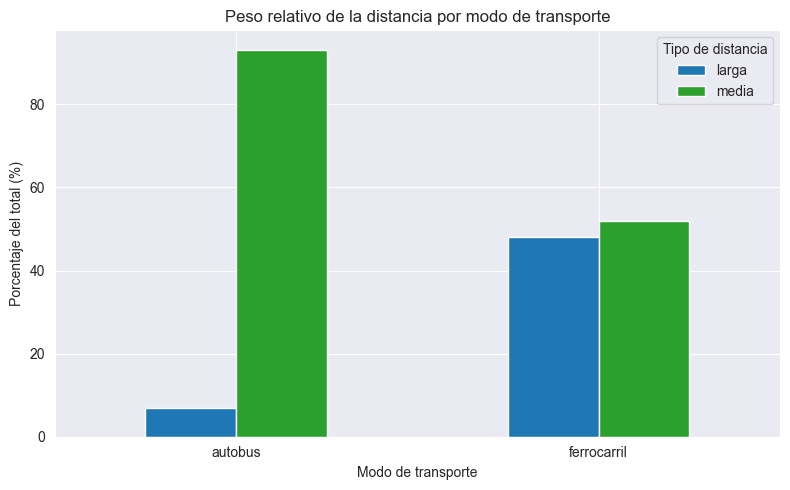

In [128]:
plt.figure(figsize=(8, 5))

pivot_distancia.plot(
    kind="bar",
    ax=plt.gca(),
    color=["tab:blue", "tab:green"]  # media / larga
)

plt.title("Peso relativo de la distancia por modo de transporte")
plt.ylabel("Porcentaje del total (%)")
plt.xlabel("Modo de transporte")
plt.xticks(rotation=0)
plt.legend(title="Tipo de distancia")

plt.tight_layout()
plt.savefig(ASSETS_DIR / "peso_relativo_distancia_por_modo.png", dpi=300)
plt.show()
plt.close()

El autobús actúa como modo dominante para desplazamientos intermedios.
El ferrocarril, aunque menos utilizado en términos absolutos, concentra una mayor proporción de viajes de larga distancia.
Esto evidencia una complementariedad funcional entre ambos modos de transporte.


# =========================
# 8A) EVOLUCIÓN ANUAL DEL PESO RELATIVO POR TIPO DE DISTANCIA
# =========================

In [129]:
distancia_anual = (
    df_terrestre.groupby(["año", "distancia_tipo"])["viajeros"]
    .sum()
    .reset_index()
)

# Calcular porcentaje dentro de cada año
distancia_anual["Porcentaje_%"] = (
    distancia_anual["viajeros"]
    / distancia_anual.groupby("año")["viajeros"].transform("sum")
    * 100
).round(2)

print("\n===== EVOLUCIÓN ANUAL DEL PESO RELATIVO POR DISTANCIA =====")
print(distancia_anual)



===== EVOLUCIÓN ANUAL DEL PESO RELATIVO POR DISTANCIA =====
    año distancia_tipo   viajeros  Porcentaje_%
0  2023          larga   57123000         17.28
1  2023          media  273406000         82.72
2  2024          larga   67695000         17.94
3  2024          media  309704000         82.06
4  2025          larga   67607000         18.23
5  2025          media  303237000         81.77


# =========================
# 8B) GRÁFICO: EVOLUCIÓN DEL PESO RELATIVO POR DISTANCIA (EJE X CORREGIDO)
# =========================

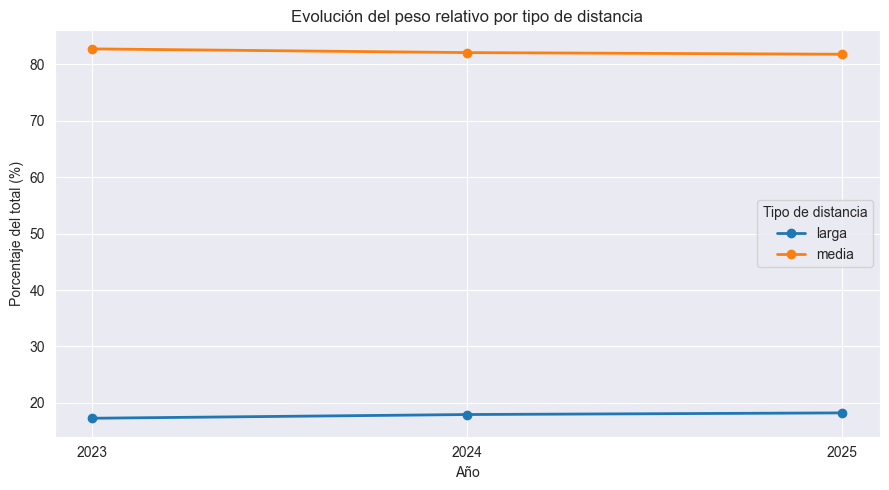

In [131]:
pivot_distancia_anual = distancia_anual.pivot(
    index="año",
    columns="distancia_tipo",
    values="Porcentaje_%"
).sort_index()

plt.figure(figsize=(9, 5))

for dist in pivot_distancia_anual.columns:
    plt.plot(
        pivot_distancia_anual.index,
        pivot_distancia_anual[dist],
        marker="o",
        linewidth=2,
        label=dist
    )

plt.title("Evolución del peso relativo por tipo de distancia")
plt.xlabel("Año")
plt.ylabel("Porcentaje del total (%)")
plt.legend(title="Tipo de distancia")

# 👉 Forzar eje X a años enteros (SIN 2024.25, etc.)
ax = plt.gca()
ax.set_xticks(pivot_distancia_anual.index)
ax.set_xticklabels(pivot_distancia_anual.index.astype(int))

plt.tight_layout()
plt.savefig(ASSETS_DIR/ "evolucion_peso_relativo_distancia.png", dpi=300)
plt.show()
plt.close()

El autobús constituye el pilar principal de la movilidad terrestre en España, concentrando la mayor parte del volumen total de viajeros durante todo el período analizado.
La evolución mensual evidencia patrones estacionales comunes entre modos, lo que sugiere que ambos están influenciados por factores compartidos como movilidad recurrente y periodos vacacionales.
No se observan cruces ni convergencias entre modos, lo que confirma una diferencia estructural y persistente en el volumen de demanda entre autobús y ferrocarril.
Existe una relación clara entre modo de transporte y tipo de distancia:
El autobús se orienta mayoritariamente a desplazamientos de media distancia.
El ferrocarril, aunque con menor volumen absoluto, concentra una mayor proporción relativa de viajes de larga distancia.
La estructura de la movilidad se mantiene estable en el tiempo, indicando que los cambios observados responden principalmente a variaciones de volumen y no a transformaciones en la naturaleza de los desplazamientos.
